In [10]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.linear_model import LogisticRegression
import seaborn as sns


In [2]:
hw = pd.read_csv('homework_4.1.csv')
hw

,Z,W,X,Y
0,0,-0.155644,-0.496971,0.282484
1,1,0.529539,2.284240,4.740596
2,1,0.910514,0.872232,3.449569
3,1,-0.705476,2.157260,3.002531
4,0,-0.590874,-0.386730,-1.848796
...,...,...,...,...
4995,0,-0.976289,0.482060,-0.830112
4996,0,0.677586,-0.580264,1.106948
4997,0,-0.829560,0.895967,-0.612659
4998,0,-1.126846,-0.178558,-2.882220


In [ ]:
df = hw

mean_y_z1 = df[df["Z"] == 1]["Y"].mean()
mean_y_z0 = df[df["Z"] == 0]["Y"].mean()
delta_y = mean_y_z1 - mean_y_z0

# Step B: Subtract average X for Z=1 and Z=0
mean_x_z1 = df[df["Z"] == 1]["X"].mean()
mean_x_z0 = df[df["Z"] == 0]["X"].mean()
delta_x = mean_x_z1 - mean_x_z0

# Step C: Divide the two
method_1_effect = delta_y / delta_x

print("--- Method 1 (Global Wald) ---")
print(f"ΔY (Z=1 minus Z=0): {delta_y:.4f}")
print(f"ΔX (Z=1 minus Z=0): {delta_x:.4f}")
print(f"Estimated Effect:    {method_1_effect:.4f}\n")

df["W_bin"] = pd.qcut(df["W"], q=25, labels=False)
print()
print('----------Method 2----------')
stratified_effects = []

# Loop through each narrow range of W
for bin_id in sorted(df["W_bin"].unique()):
    sub_df = df[df["W_bin"] == bin_id]

    # Calculate means within this narrow range
    sub_y_z1 = sub_df[sub_df["Z"] == 1]["Y"].mean()
    sub_y_z0 = sub_df[sub_df["Z"] == 0]["Y"].mean()

    sub_x_z1 = sub_df[sub_df["Z"] == 1]["X"].mean()
    sub_x_z0 = sub_df[sub_df["Z"] == 0]["X"].mean()

    # Take the ratio for this specific bin (if denominator isn't 0)
    denom = sub_x_z1 - sub_x_z0
    if denom != 0:
        bin_effect = (sub_y_z1 - sub_y_z0) / denom
        stratified_effects.append(bin_effect)

# Average the ratios over all ranges of W
method_2_effect = np.mean(stratified_effects)

print("--- Method 2 (Stratified over W) ---")
print(f"Number of W bins evaluated: {len(stratified_effects)}")
print(f"Estimated Effect:           {method_2_effect:.4f}")

--- Method 1 (Global Wald) ---
ΔY (Z=1 minus Z=0): 1.5908
ΔX (Z=1 minus Z=0): 1.0186
Estimated Effect:    1.5619


----------Method 2----------
--- Method 2 (Stratified over W) ---
Number of W bins evaluated: 25
Estimated Effect:           1.5139


## Question 3

In [7]:
df2 = pd.read_csv('homework_4.2.a.csv')
df3 = pd.read_csv('homework_4.2.b.csv')

print(df2.head())
print(df3.head())

           X  Y
0  81.822339  1
1  92.487870  0
2  85.372460  0
3  78.828025  0
4  75.807080  1
          X2  Y2
0  76.643034   1
1  87.743397   1
2  81.639469   1
3  73.740485   0
4  90.480268   1


<Axes: xlabel='X', ylabel='Y'>

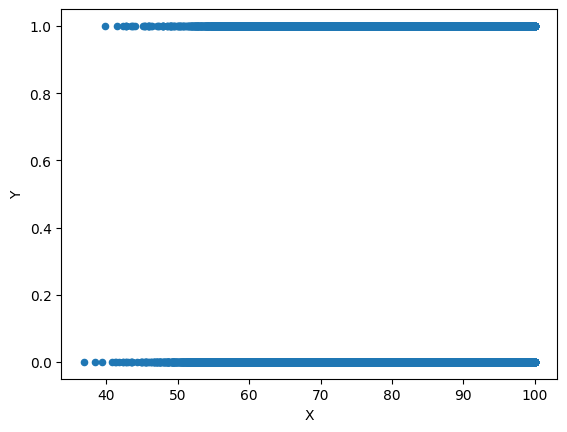

In [10]:
df2.plot.scatter('X','Y')

<Axes: xlabel='X2', ylabel='Y2'>

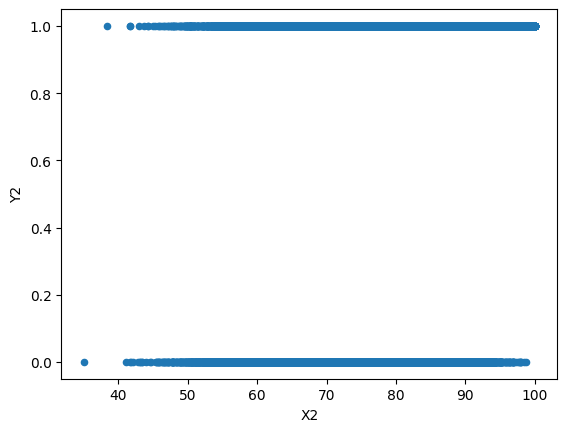

In [11]:
df3.plot.scatter('X2','Y2')

In [14]:
cutoff = 80
df1 = df3.copy()
df1['X'] = df1['X2']
df1['Y'] = df1['Y2']

for i, df in enumerate([df2, df1], start=1):
    df['X_centered'] = df['X'] - cutoff
    df['D'] = (df['X'] >= cutoff).astype(int)       # 1 if >= 80, else 0
    df['Interaction'] = df['X_centered'] * df['D']  # Changes slope after cutoff
    
    # Fit Ordinary Least Squares (OLS) model
    X_vars = sm.add_constant(df[['X_centered', 'D', 'Interaction']])
    model = sm.OLS(df['Y'], X_vars).fit()
    
    # Extract coefficients
    b1 = model.params['X_centered']
    b3 = model.params['Interaction']
    slope_after = b1 + b3
    
    print(f"--- Dataset {i} Linear Terms ---")
    print(f"Linear Slope Before Cutoff (b1): {b1: .4f}")
    print(f"Linear Slope After Cutoff (b1+b3): {slope_after: .4f}\n")

--- Dataset 1 Linear Terms ---
Linear Slope Before Cutoff (b1):  0.0002
Linear Slope After Cutoff (b1+b3):  0.0002

--- Dataset 2 Linear Terms ---
Linear Slope Before Cutoff (b1):  0.0102
Linear Slope After Cutoff (b1+b3):  0.0050



In [ ]:
# quizzes = [6/10,6/10,8/10,1/1,4/10]
# coding = [36/43,26/43,18/44,32/40]
# quiz_avg = sum(quizzes)/len(quizzes)
# code_avg = sum(coding)/len(coding)
# grade = .14 * quiz_avg + .53 * code_avg + .33*.75

# print(f'Quiz grade is: {quiz_avg:.2f}. Coding grade is: {code_avg:.2f}. max grade is {grade *100:.2f}%')



Quiz grade is: 0.68. Coding grade is: 0.66. max grade is 69.40%


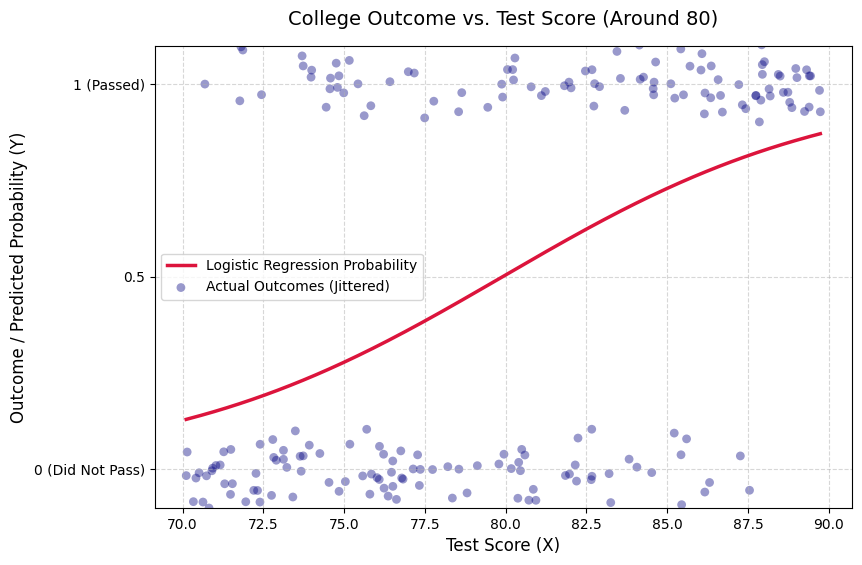

In [13]:
np.random.seed(42)
X = np.random.uniform(70, 90, 200)

# Simulate log-odds and convert to probabilities
beta_0, beta_1 = -16, 0.2  # Arbitrary coefficients for the example
log_odds = beta_0 + beta_1 * X
probabilities = 1 / (1 + np.exp(-log_odds))

# Simulate binary Y (0 or 1) based on these probabilities
Y = np.random.binomial(1, probabilities)

# Logistic Regression
X_reshaped = X.reshape(-1, 1)
reg_scores = LogisticRegression()
reg_scores.fit(X_reshaped, Y)

# Generate a continuous range of X for the probability curve
X_smooth = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
y_prob = reg_scores.predict_proba(X_smooth)[:, 1]

# 3. Plotting
plt.figure(figsize=(9, 6))

# # Plot the predicted probability curve
# sns.lineplot(x=X.flatten(), y=Y.flatten(), color='crimson', 
#              linewidth=2.5, label='Logistic Regression Probability')
sns.lineplot(x=X_smooth.flatten(), y=y_prob, color='crimson', 
             linewidth=2.5, label='Logistic Regression Probability')


# Jitter (0.05) avoids obscuring points, while alpha (0.4) shows density
np.random.seed(100) # Fix jitter for consistency
y_jittered = Y + np.random.normal(0, 0.05, size=len(Y))
sns.scatterplot(x=X, y=y_jittered, alpha=0.4, color='navy', 
                edgecolor='none', s=40, label='Actual Outcomes (Jittered)')

plt.title('College Outcome vs. Test Score (Around 80)', fontsize=14, pad=15)
plt.xlabel('Test Score (X)', fontsize=12)
plt.ylabel('Outcome / Predicted Probability (Y)', fontsize=12)
plt.yticks([0, 0.5, 1], ['0 (Did Not Pass)', '0.5', '1 (Passed)'])
plt.ylim(-0.1, 1.1)
plt.legend(loc='center left', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
